### Условие задачи

Вы — аналитик международной компании по производству климатического оборудования. Вам переданы данные полевого исследования об использовании систем
кондиционирования в офисах различных стран, включая объективные замеры среды и субъективные оценки комфорта респондентов.

Задача: на основе анализа данных определить, в развитие каких типов оборудования целесообразно инвестировать для повышения удовлетворенности
клиентов в разных регионах, и выявить региональные особенности для стратегии развития бизнеса.

В рамках работы требуется:

1. Предобработка данных: приведение к стандартам (PEP8), коррекция типов, обработка выбросов, пропусков и дубликатов.
2. Расчетная часть: создание категорий по рекламациям и возрасту, групповые расчеты средних и медианных значений комфортной среды, анализ соответствия влажности стандартам, исследование корреляций.
3. Проверка статистических гипотез: оценка влияния типа охлаждения, пола, возраста, страны и количества рекламаций на уровень комфорта (плюс 3 собственные гипотезы).
4. Моделирование: построение регрессионной модели для прогноза температуры в помещении в зависимости от типа системы и других значимых факторов.

По итогам ожидаются выводы для принятия решений.

### Импорт необходимых библиотек

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import kruskal, mannwhitneyu
from scipy.stats import spearmanr

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('Данные по использованию климатических систем.csv', sep=';')
df

,Год,Время года,Климат,Город,Страна,Способ охлаждения,Режим при смешанном типе охлаждения,Способ обогрева,Возраст,Пол,...,Скорость воздуха,Рост,Вес,Занавески,Вентилятор,Окно,Двери,Отопление,Среднемесячная температура на улице,Количество рекламаций
0,2011.0,Лето,Cубтропический океанический,Техас,США,Кондиционирование,NaN,NaN,22.0,NaN,...,0.26,NaN,NaN,1.0,1.0,NaN,NaN,NaN,28.9,0
1,2011.0,Лето,Cубтропический океанический,Техас,США,Кондиционирование,NaN,NaN,40.0,NaN,...,0.12,NaN,NaN,0.0,0.0,NaN,NaN,NaN,84.0,0
2,2011.0,Лето,Cубтропический океанический,Техас,США,Кондиционирование,NaN,NaN,42.0,NaN,...,0.08,NaN,NaN,0.0,0.0,NaN,NaN,NaN,32.8,0
3,2011.0,Лето,Cубтропический океанический,Техас,США,Кондиционирование,NaN,NaN,27.0,NaN,...,27.16,NaN,NaN,1.0,1.0,NaN,NaN,NaN,28.9,1
4,2011.0,Лето,Cубтропический океанический,Техас,США,Кондиционирование,NaN,NaN,46.0,NaN,...,63.83,NaN,NaN,1.0,1.0,NaN,NaN,NaN,32.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,2012.0,Лето,Влажный субтропический муссонный,Дели,Индия,Смешанный,Вентиляция,NaN,35.0,Мужской,...,0.32,172.7,50.0,NaN,1.0,1.0,NaN,0.0,30.9,0
480,2012.0,Зима,Тропическая влажная саванна,Ченнай,Индия,Смешанный,Кондиционирование,NaN,NaN,Мужской,...,0.16,NaN,65.0,NaN,NaN,0.0,0.0,NaN,30.8,0
481,2012.0,Зима,Жаркий полузасушливый,Хайдарабад,Индия,Смешанный,Кондиционирование,NaN,NaN,Женский,...,0.02,NaN,76.0,NaN,NaN,0.0,0.0,NaN,21.6,0
482,2012.0,Зима,Жаркий полузасушливый,Хайдарабад,Индия,Смешанный,Кондиционирование,NaN,NaN,Женский,...,0.02,NaN,76.0,NaN,NaN,0.0,0.0,NaN,21.6,0


# Исследование данных на качество и предобработка

In [75]:
df.columns = df.columns.str.lower().str.replace(' ', '_')  # переводим названия столбцов в соответствии с PEP8

In [76]:
df_raw = df.copy()

## Обработка выбросов и ошибок масштаба

In [77]:
# исследуем данные на кол-во выбросов
def detect_all_outliers(df):
    numeric_columns = [
        'возраст',
        'утепление',
        'температура_воздуха_в_помещении',
        'температура_воздуха_на_улице',
        'rh',
        'скорость_воздуха',
        'рост',
        'вес',
        'среднемесячная_температура_на_улице'
    ]

    for col in numeric_columns:
        if df[col].notna().sum() > 0:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            low = q1 - 3 * iqr
            up = q3 + 3 * iqr

            outliers_count = df[(df[col] < low) | (df[col] > up)].shape[0]

            print(f"{col}: {outliers_count}")


detect_all_outliers(df)

возраст: 0
утепление: 15
температура_воздуха_в_помещении: 28
температура_воздуха_на_улице: 0
rh: 0
скорость_воздуха: 32
рост: 2
вес: 0
среднемесячная_температура_на_улице: 12


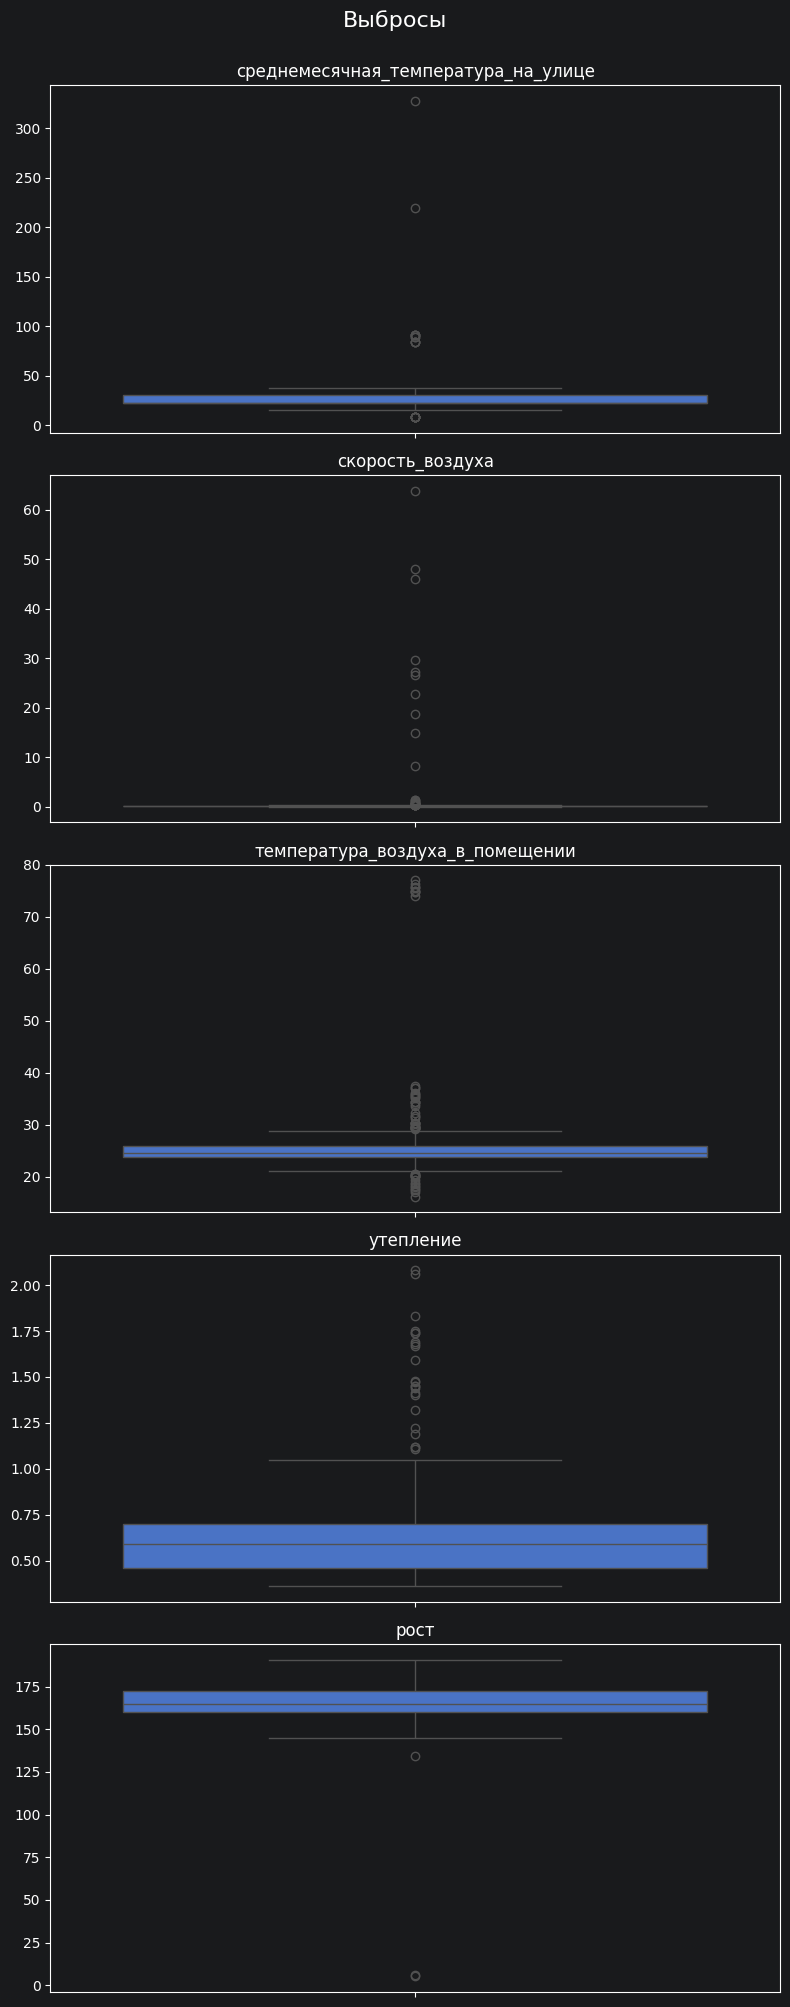

In [78]:
# выведем выбросы в данных для наглядности
columns = ['среднемесячная_температура_на_улице', 'скорость_воздуха', 'температура_воздуха_в_помещении', 'утепление',
           'рост']

fig, axes = plt.subplots(5, 1, figsize=(8, 20))
fig.suptitle('Выбросы', fontsize=16, y=1.001)

for i, col in enumerate(columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [79]:
df[df['температура_воздуха_в_помещении'] > 70]['страна'].unique()

<StringArray>
['США']
Length: 1, dtype: str

In [80]:
df[(df['среднемесячная_температура_на_улице'] > 50) & (df['среднемесячная_температура_на_улице'] < 100)][
    'страна'].unique()

<StringArray>
['США']
Length: 1, dtype: str

In [81]:
# Обработка масштабирования
# Температура в помещении
# Значения > 70, записаны в фарингейтах, т.к. все находятся в США
mask_temp_f = df['температура_воздуха_в_помещении'] > 70
df.loc[mask_temp_f, 'температура_воздуха_в_помещении'] = (
        (df.loc[mask_temp_f, 'температура_воздуха_в_помещении'] - 32) * 5 / 9
)

# Среднемесячная температура на улице
# Значения 50-100, записаны в фарингейтах, т.к. все находятся в США
mask_month_f = (
        (df['среднемесячная_температура_на_улице'] > 50) &
        (df['среднемесячная_температура_на_улице'] < 100)
)
df.loc[mask_month_f, 'среднемесячная_температура_на_улице'] = (
        (df.loc[mask_month_f, 'среднемесячная_температура_на_улице'] - 32) * 5 / 9
)

In [82]:
#конечная обработка выбросов
def remove_outliers(df, column, k=3):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    up = q3 + k * iqr

    outlier_mask = (df[column] < low) | (df[column] > up)
    df.loc[outlier_mask, column] = np.nan

    return df


df = remove_outliers(df,
                     'среднемесячная_температура_на_улице')  # возможные причины выбросов: некорректное усреднение, сбои оборудования, климатические аномалии
df = remove_outliers(df,
                     'скорость_воздуха')  # возможные причины выбросов: физические пределы, помехи при замере, ошибки датчиков
df = remove_outliers(df,
                     'температура_воздуха_в_помещении')  # возможные причины выбросов: ошибки датчиков или размещения, опечатки, разные шкалы
df = remove_outliers(df,
                     'утепление')  # возможные причины выбросов: неправильная методика расчёта, ошибки ввода (человеческий фактор)
df = remove_outliers(df, 'рост')  # возможные причины выбросов: аномалии роста, ошибки ввода (человеческий фактор)

## Обработка пропусков

In [83]:
# Размер выборки по странам
country_sizes = df.groupby('страна').size().rename('n_rows')

# Количество непустых значений по каждой стране и каждому столбцу
non_null_counts = df.groupby('страна').agg(lambda x: x.notna().sum())

# Процент заполненности по каждой стране и каждому столбцу
fill_rate = non_null_counts.div(country_sizes, axis=0).mul(100).round(1)
country_fill_table = fill_rate.T

country_fill_table

страна,Австралия,Индия,США
год,100.0,100.0,100.0
время_года,100.0,100.0,100.0
климат,100.0,100.0,100.0
город,100.0,100.0,100.0
способ_охлаждения,100.0,100.0,100.0
режим_при_смешанном_типе_охлаждения,100.0,65.0,0.0
способ_обогрева,100.0,11.2,0.0
возраст,100.0,66.8,100.0
пол,100.0,100.0,0.0
ощущение_температуры,100.0,100.0,100.0


Функция для заполнения по иерархии, чтобы точность данных была приближена к похожим сценариям

In [84]:
def fill_numeric_by_hierarchy(df, column, hierarchy):
    filled = df[column].copy()

    for group_cols in hierarchy:
        group_median = df.groupby(group_cols)[column].transform('median')
        filled = filled.fillna(group_median)

    filled = filled.fillna(df[column].median())
    return filled

Если способ охлаждения не смешанный, пропуск в этом столбце считается структурным, потому что режим смешанного охлаждения в таком случае просто не применим

In [85]:
# Режим при смешанном типе охлаждения
mask_not_mixed = (
        df['способ_охлаждения'].notna() &
        (df['способ_охлаждения'] != 'Смешанный') &
        (df['режим_при_смешанном_типе_охлаждения'].isna())
)
df.loc[mask_not_mixed, 'режим_при_смешанном_типе_охлаждения'] = 'NA'

mask_mixed_unknown = (
        (df['способ_охлаждения'] == 'Смешанный') &
        (df['режим_при_смешанном_типе_охлаждения'].isna())
)
df.loc[mask_mixed_unknown, 'режим_при_смешанном_типе_охлаждения'] = 'неизвестно'

Если значение пропущено летом или при выключенном отоплении, оно интерпретируется как Nan, то есть обогрев в этих условиях, не использовался, остальные пропуски помечаются как неизвестно, чтобы не подставлять необоснованные категории

In [86]:
# Способ обогрева
mask_heating_na = (df['способ_обогрева'].isna() & ((df['время_года'] == 'Лето') | (df['отопление'] == 0)))
df.loc[mask_heating_na, 'способ_обогрева'] = 'NA'
df['способ_обогрева'] = df['способ_обогрева'].fillna('неизвестно')

Пропуски температуры в помещении заполнялись по максимально близким условиям, это позволяет учитывать, что температура внутри помещения зависит от региона и режима эксплуатации системы

При этом сохраняется маска того, где у нас реальные данные, это будет важно для регрессионной модели

In [87]:
# Температура воздуха в помещении
target_mask = df['температура_воздуха_в_помещении'].notna().copy()

df['температура_воздуха_в_помещении'] = fill_numeric_by_hierarchy(
    df=df,
    column='температура_воздуха_в_помещении',
    hierarchy=[
        ['страна', 'время_года', 'способ_охлаждения'],
        ['страна', 'способ_охлаждения'],
        ['страна']
    ]
)

Скорость воздуха восстанавливалась по стране, способу охлаждения и времени года, т.к. именно эти факторы сильнее всего влияют на воздушный режим в помещении

In [88]:
df['скорость_воздуха'] = fill_numeric_by_hierarchy(
    df=df,
    column='скорость_воздуха',
    hierarchy=[
        ['страна', 'способ_охлаждения', 'время_года'],
        ['страна', 'способ_охлаждения'],
        ['способ_охлаждения']
    ]
)

In [89]:
# Возраст
df['возраст'] = fill_numeric_by_hierarchy(df=df, column='возраст', hierarchy=[['страна', 'пол'], ['страна']])

Для проверки гипотезы о комфортности создадим отдельные датафреймы по уровню комфорта и половом распределении, т.к. по этим пунктам в основном маленькая заполненость данных или отсутствие данных по какой-то страны и срез по пропускам может повлиять на другие метрики

In [90]:
df_comfort = df[df['оценка_комфорта'].notna()].copy()
df['пол'] = df['пол'].fillna('неизвестно')
df_gender = df[df['пол'].notna() & df['оценка_комфорта'].notna()].copy()

Остальные метрики либо отсутствую в некоторых странах или их заполненность низка, либо не сильно влияют на дальнейший анализ

In [91]:
missing_before = df_raw.isna().sum().sort_values(ascending=False)
missing_before = missing_before[missing_before > 0]

missing_after = df.isna().sum().sort_values(ascending=False)
missing_after = missing_after[missing_after > 0]

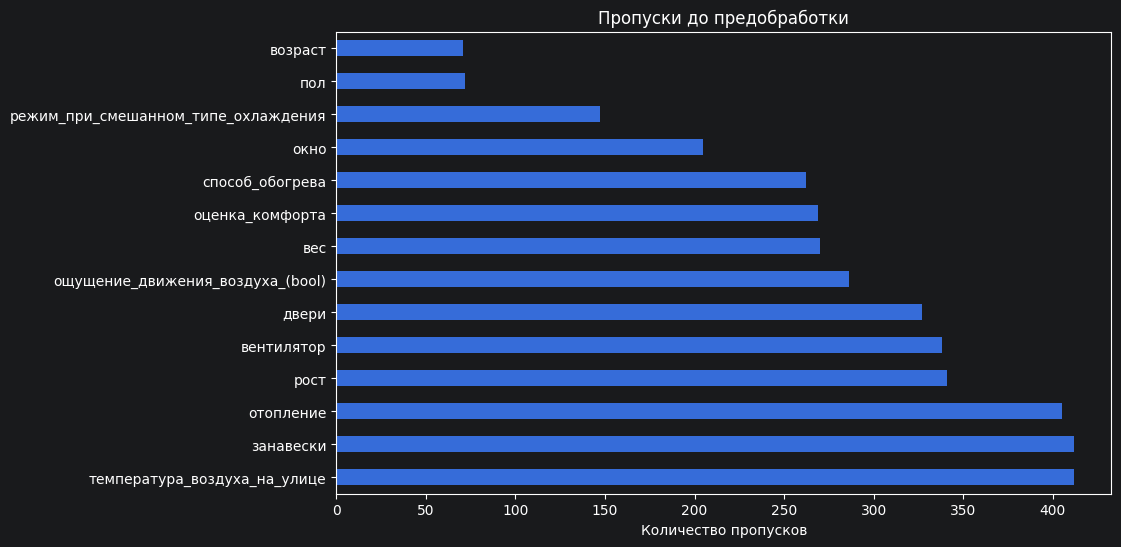

In [92]:
plt.figure(figsize=(10, 6))
missing_before.plot(kind='barh')
plt.title('Пропуски до предобработки')
plt.xlabel('Количество пропусков')
plt.show()

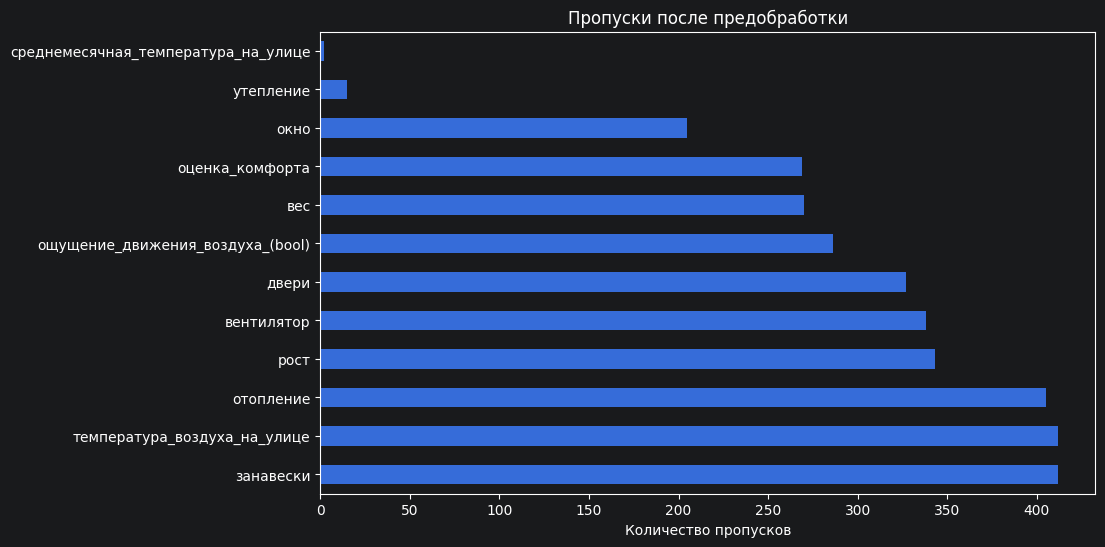

In [93]:
plt.figure(figsize=(10, 6))
missing_after.plot(kind='barh')
plt.title('Пропуски после предобработки')
plt.xlabel('Количество пропусков')
plt.show()

До предобработки в данных были пропуски в нескольких признаках, после заполнения их количество сократилось, при этом признаки с большим количеством пропусков не заполнялись в избежании некорректности заполнения

## Обработка дубликатов

In [94]:
# проверка данных на дубликаты
print('Размер датафрейма:', df.shape)
print('Полных дубликатов:', df.duplicated().sum())
df[df.duplicated()].head()

Размер датафрейма: (484, 30)
Полных дубликатов: 2


,год,время_года,климат,город,страна,способ_охлаждения,режим_при_смешанном_типе_охлаждения,способ_обогрева,возраст,пол,...,скорость_воздуха,рост,вес,занавески,вентилятор,окно,двери,отопление,среднемесячная_температура_на_улице,количество_рекламаций
482,2012.0,Зима,Жаркий полузасушливый,Хайдарабад,Индия,Смешанный,Кондиционирование,неизвестно,35.0,Женский,...,0.02,NaN,76.0,NaN,NaN,0.0,0.0,NaN,21.6,0
483,2012.0,Зима,Жаркий полузасушливый,Хайдарабад,Индия,Смешанный,Кондиционирование,неизвестно,35.0,Женский,...,0.02,NaN,76.0,NaN,NaN,0.0,0.0,NaN,21.6,0


In [95]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print('\n')
    print(df[col].value_counts())



время_года
Лето     372
Зима      81
Весна     18
Осень     13
Name: count, dtype: int64


климат
Cубтропический океанический         269
Тропическая влажная саванна          77
Жаркий полузасушливый                70
Влажный субтропический муссонный     35
Субтропическое высокогорье           32
Cубтроп океанич                       1
Name: count, dtype: int64


город
Сидней        198
Техас          72
Ченнай         51
Ахмедабад      38
Дели           35
Шимла          32
Хайдарабад     32
Бангалор       26
Name: count, dtype: int64


страна
Индия        214
Австралия    198
США           72
Name: count, dtype: int64


способ_охлаждения
Смешанный            337
Кондиционирование    114
Вентиляция            33
Name: count, dtype: int64


режим_при_смешанном_типе_охлаждения
Кондиционирование    237
NA                   147
Вентиляция           100
Name: count, dtype: int64


способ_обогрева
Механическое отопление    222
NA                        166
неизвестно                 96
Na

/var/folders/sk/r233dnbx0h72083z0n8g8_2h0000gn/T/ipykernel_2259/3589264658.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [96]:
# Удаляем полные дубликаты
df = df.drop_duplicates().copy()

# Исправляем неявные дубликаты в климате
df['климат'] = df['климат'].replace({
    'Cубтроп океанич': 'Субтропический океанический',
    'Cубтропический океанический': 'Субтропический океанический'
})

# Исправляем неявные дубликаты в предпочтительном изменении температуры
df['предпочтительное_изменение_температуры'] = (
    df['предпочтительное_изменение_температуры']
    .replace({
        'Холодн': 'Холоднее',
        'Тепле': 'Теплее'
    })
)

---

# Проведение расчётов и исследований

In [97]:
# создаем новый категориальный столбец, который покажет количество рекламаций по каждому клиенту отдельно
df['количество_рекламаций_кат'] = df['количество_рекламаций'].apply(
    lambda x: 'мало' if x <= 1 else ('средне' if x == 2 else 'много'))

In [98]:
# рассчитываем средний возраст респондентов по полу и стране
avg_age = df.groupby(['страна', 'пол'])['возраст'].mean().round(2)
print(avg_age)

страна     пол       
Австралия  Женский       46.35
           Мужской       42.61
Индия      Женский       36.04
           Мужской       37.28
США        неизвестно    36.21
Name: возраст, dtype: float64


In [99]:
# разделяем респондентов на 3 категории по возрасту
df['возраст_кат'] = df['возраст'].apply(
    lambda x: 'молодой возраст' if x <= 44 else ('средний возраст' if x <= 59 else 'пожилой возраст'))

In [100]:
# рассчитываем среднюю комфортную температуру в зависимости от возрастной категории
avg_comf_temp = df.groupby('возраст_кат')['температура_воздуха_в_помещении'].mean().round(2)
print(avg_comf_temp)

возраст_кат
молодой возраст    25.12
пожилой возраст    25.22
средний возраст    24.18
Name: температура_воздуха_в_помещении, dtype: float64


In [101]:
# рассчитываем медианное значение температуры и влажности для каждого типа охлаждения
df['температура_воздуха_в_помещении'] = pd.to_numeric(df['температура_воздуха_в_помещении'], errors='coerce')
df['rh'] = pd.to_numeric(df['rh'], errors='coerce')

stat_temp_values = df.groupby('способ_охлаждения').agg(
    медианная_температура=('температура_воздуха_в_помещении', 'median'), медианная_влажность=('rh', 'median')).round(2)

print(stat_temp_values)

                   медианная_температура  медианная_влажность
способ_охлаждения                                            
Вентиляция                         25.30                46.30
Кондиционирование                  24.28                42.45
Смешанный                          24.70                56.50


In [102]:
# создаем столбец с процентом удовлетворенных респондентов температурой воздуха в помещении относительно всех респондентов одной страны и одного пола
df['удовлетворённость_температурой'] = (df['ощущение_температуры_(bool)'] == 1.0).astype(int)

df['процент_удовлетворённых'] = df.groupby(['страна', 'пол'])['удовлетворённость_температурой'].transform(
    lambda x: (x.sum() / x.count() * 100).round(2))

print(df[['страна', 'пол', 'удовлетворённость_температурой', 'процент_удовлетворённых']].head(10))

  страна         пол  удовлетворённость_температурой  процент_удовлетворённых
0    США  неизвестно                               1                     75.0
1    США  неизвестно                               1                     75.0
2    США  неизвестно                               1                     75.0
3    США  неизвестно                               0                     75.0
4    США  неизвестно                               1                     75.0
5    США  неизвестно                               1                     75.0
6    США  неизвестно                               1                     75.0
7    США  неизвестно                               1                     75.0
8    США  неизвестно                               1                     75.0
9    США  неизвестно                               0                     75.0


In [103]:
# создаем сводную таблицу, в которой данные будут сгруппированы по стране, полу, возрастной группе и подсчитаны средняя температура воздуха в помещении, на улице и средняя относительная влажность для каждой из этих групп
pivot_table = df.groupby(['страна', 'пол', 'возраст_кат']).agg(
    средняя_температура_в_помещении=('температура_воздуха_в_помещении', 'mean'),
    средняя_температура_на_улице=('температура_воздуха_на_улице', 'mean'),
    средняя_относительная_влажность=('rh', 'mean'),
    количество=('rh', 'count')).round(2)

print(pivot_table)

                                      средняя_температура_в_помещении  \
страна    пол        возраст_кат                                        
Австралия Женский    молодой возраст                            23.84   
                     пожилой возраст                            24.90   
                     средний возраст                            24.11   
          Мужской    молодой возраст                            24.15   
                     пожилой возраст                            24.73   
                     средний возраст                            24.04   
Индия     Женский    молодой возраст                            25.94   
                     средний возраст                            23.69   
          Мужской    молодой возраст                            25.97   
                     пожилой возраст                            29.30   
                     средний возраст                            24.57   
США       неизвестно молодой возраст               

In [104]:
# создаем новый столбец, в котором будет показано, удовлетворяет ли зафиксированная относительная влажность стандарту или нет
def categorize(rh):
    if 30 <= rh <= 60:
        return 'да'
    else:
        return 'нет'


df['стандарт_rh'] = df['rh'].apply(categorize)

In [105]:
numeric_cols = [
    'возраст',
    'ощущение_температуры',
    'оценка_комфорта',
    'температура_воздуха_в_помещении',
    'температура_воздуха_на_улице',
    'rh',
    'скорость_воздуха',
    'количество_рекламаций'
]

display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
возраст,482.0,39.827801,10.371549,22.0,35.00,35.00,45.000,65.00
ощущение_температуры,482.0,0.208299,1.091478,-3.0,0.00,0.00,1.000,3.00
оценка_комфорта,215.0,4.772093,1.261161,1.0,4.00,5.00,6.000,6.00
температура_воздуха_в_помещении,482.0,24.759843,1.848890,18.3,23.80,24.60,25.700,30.40
температура_воздуха_на_улице,72.0,24.104167,0.604546,22.8,23.80,24.10,24.400,25.90
rh,482.0,53.019295,13.044019,23.8,42.85,53.85,62.375,85.10
скорость_воздуха,482.0,0.105560,0.071041,0.0,0.06,0.09,0.130,0.38
количество_рекламаций,482.0,0.105809,0.441138,0.0,0.00,0.00,0.000,3.00


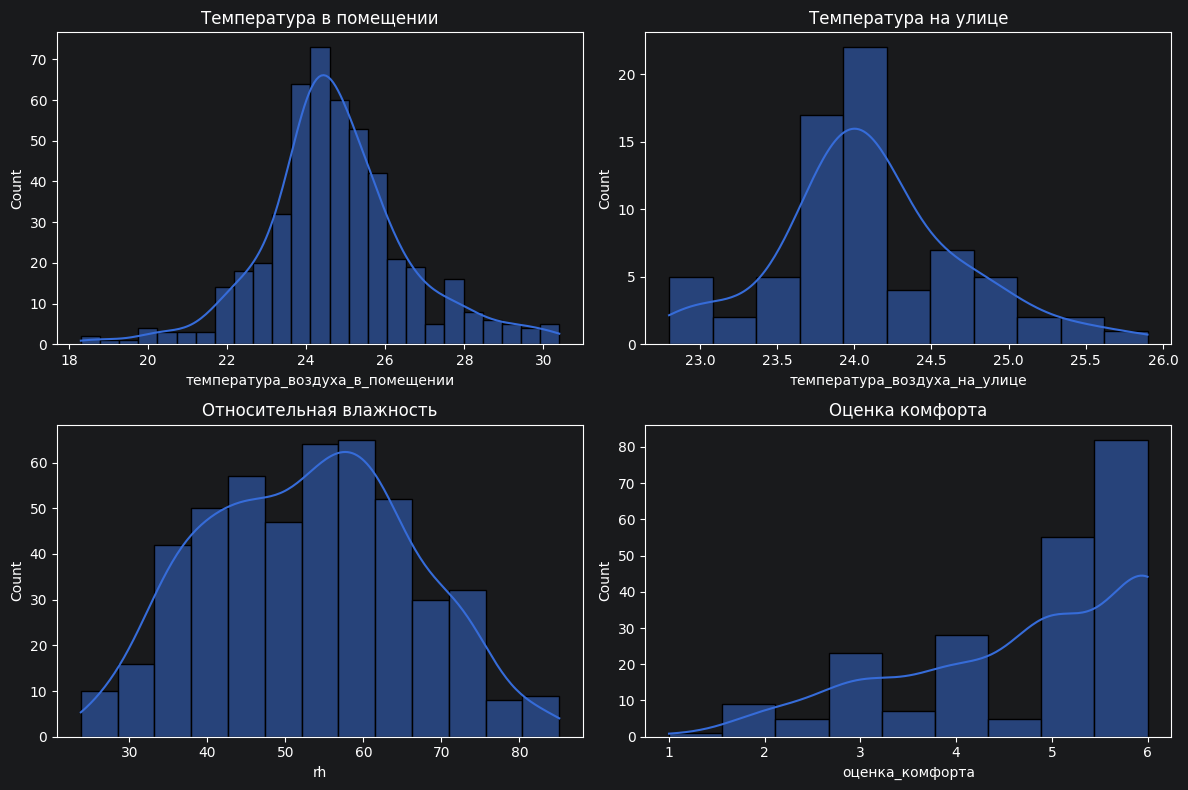

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['температура_воздуха_в_помещении'].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Температура в помещении')

sns.histplot(df['температура_воздуха_на_улице'].dropna(), kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Температура на улице')

sns.histplot(df['rh'].dropna(), kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Относительная влажность')

sns.histplot(df['оценка_комфорта'].dropna(), kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Оценка комфорта')

plt.tight_layout()
plt.show()

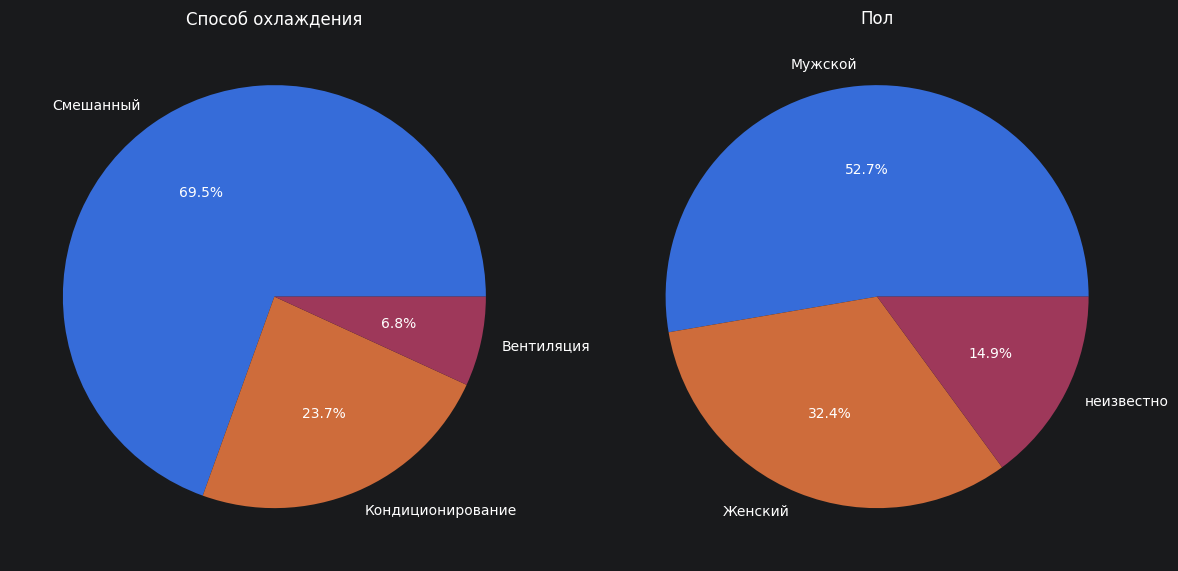

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

df['способ_охлаждения'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0]
)
axes[0].set_title('Способ охлаждения')
axes[0].set_ylabel('')

df['пол'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1]
)
axes[1].set_title('Пол')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Описательные статистики и графики показали основные диапазоны значений температуры, влажности и оценки комфорта, по категориальным признакам видно распределение респондентов по полу и типу охлаждения

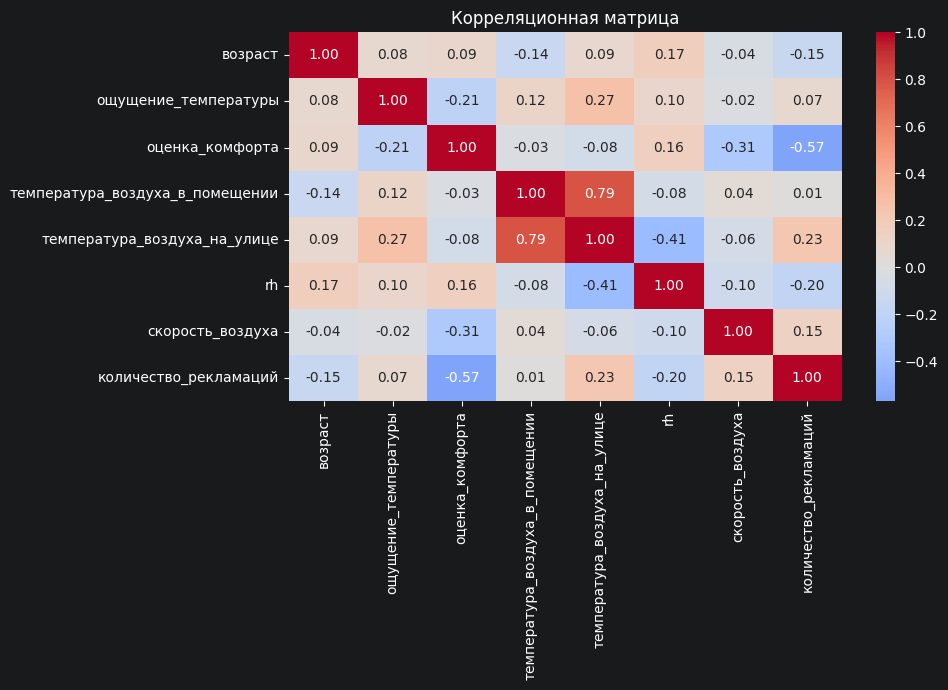

In [108]:
corr_cols = [
    'возраст',
    'ощущение_температуры',
    'оценка_комфорта',
    'температура_воздуха_в_помещении',
    'температура_воздуха_на_улице',
    'rh',
    'скорость_воздуха',
    'количество_рекламаций'
]

corr_matrix = df[corr_cols].corr(method='spearman')

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

Самая сильная положительная корреляция наблюдается между температурой воздуха в помещении и температурой на улице (0.79), что указывает на сильную связь внутреннего микроклимата с внешними условиями

Самая сильная отрицательная корреляция между оценкой комфорта и количеством рекламаций (-0.57), чем ниже комфорт, тем больше жалоб

Также заметны умеренные связи между температурой на улице и влажностью (-0.41), а также между оценкой комфорта и скоростью воздуха (-0.31).

Остальные зависимости в основном слабые.

# Проверка гипотез

### Влияет ли способ охлаждения на оценку комфорта?

In [109]:
def cat_num_nonparametric(df, cat_col, num_col, drop_unknown=False):
    data = df[[cat_col, num_col]].dropna().copy()

    if drop_unknown:
        data = data[data[cat_col] != 'неизвестно'].copy()

    grouped = list(data.groupby(cat_col))
    group_names = [name for name, _ in grouped]
    groups = [group[num_col].values for _, group in grouped]

    if len(groups) < 2:
        raise ValueError('Для теста нужно минимум 2 группы.')

    print(f'Фактор: {cat_col}')
    print(f'Отклик: {num_col}')
    print()
    print('Описательные статистики по группам:')
    print(
        data.groupby(cat_col)[num_col]
        .agg(['count', 'median', 'mean'])
        .rename(columns={'count': 'n', 'median': 'median', 'mean': 'mean'})
        .round(3)
    )
    print()

    if len(groups) == 2:
        stat, p_value = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        test_name = 'U-критерий Манна–Уитни'
    else:
        stat, p_value = kruskal(*groups)
        test_name = 'Критерий Краскела–Уоллиса'

    print(f'Используемый тест: {test_name}')
    print(f'Группы: {group_names}')
    print(f'Статистика: {stat:.4f}')
    print(f'p-value: {p_value:.6f}')

    alpha = 0.05
    if p_value < alpha:
        print(f'Вывод: различия статистически значимы при alpha = {alpha}.')
    else:
        print(f'Вывод: статистически значимых различий не обнаружено при alpha = {alpha}.')

    return p_value

In [110]:
p_value = cat_num_nonparametric(
    df=df_comfort,
    cat_col='способ_охлаждения',
    num_col='оценка_комфорта'
)

Фактор: способ_охлаждения
Отклик: оценка_комфорта

Описательные статистики по группам:
                     n  median   mean
способ_охлаждения                    
Вентиляция          33     6.0  5.091
Кондиционирование  114     5.0  4.632
Смешанный           68     5.0  4.853

Используемый тест: Критерий Краскела–Уоллиса
Группы: ['Вентиляция', 'Кондиционирование', 'Смешанный']
Статистика: 5.3963
p-value: 0.067330
Вывод: статистически значимых различий не обнаружено при alpha = 0.05.


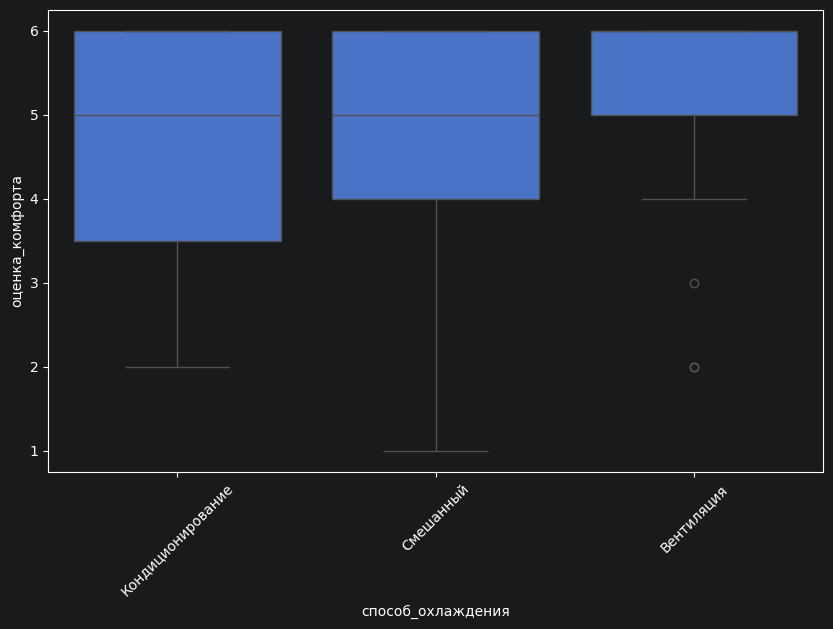

In [111]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='способ_охлаждения', y='оценка_комфорта')
plt.xticks(rotation=45)
plt.show()

Вывод:

- Нет, способ охлаждения статистически значимо не влияет на оценку комфорта.
- `p-value = 0.067330 > 0.05` → нулевая гипотеза не отвергается.
- На уровне значимости `5%` нет оснований утверждать, что распределение оценок комфорта различается между группами с вентиляцией, кондиционированием и смешанным типом охлаждения.
- Наблюдаемые различия в медианах и разбросе оценок присутствуют, но статистически значимыми не являются.

### Влияет ли пол на оценку комфорта?

In [112]:
df_gender_test = df[['пол', 'оценка_комфорта']].dropna().copy()
df_gender_test = df_gender_test[df_gender_test['пол'].isin(['Мужской', 'Женский'])]

p_value = cat_num_nonparametric(
    df=df_gender_test,
    cat_col='пол',
    num_col='оценка_комфорта'
)

Фактор: пол
Отклик: оценка_комфорта

Описательные статистики по группам:
          n  median   mean
пол                       
Женский  44     5.0  4.909
Мужской  99     6.0  5.131

Используемый тест: U-критерий Манна–Уитни
Группы: ['Женский', 'Мужской']
Статистика: 1848.5000
p-value: 0.121113
Вывод: статистически значимых различий не обнаружено при alpha = 0.05.


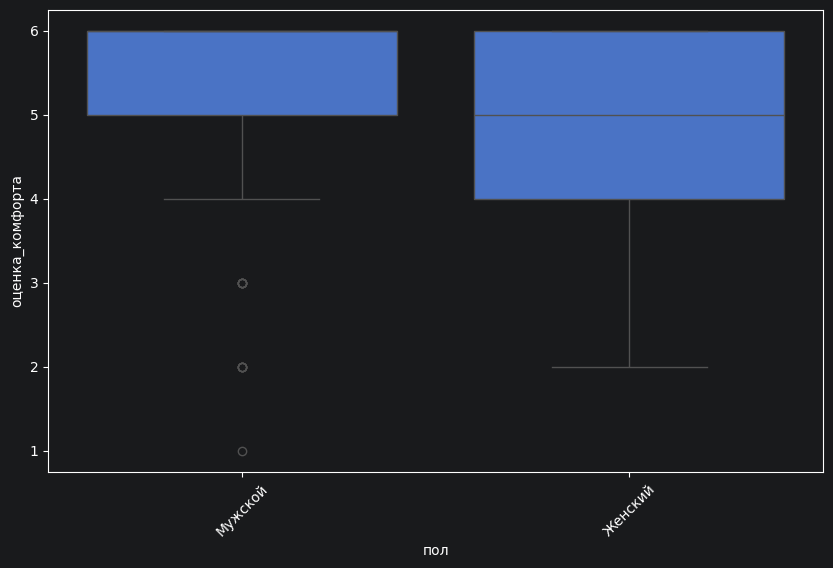

In [113]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_gender_test, x='пол', y='оценка_комфорта')
plt.xticks(rotation=45)
plt.show()

Вывод:

- Нет, пол статистически значимо не влияет на оценку комфорта.
- `p-value = 0.121113 > 0.05` → нулевая гипотеза не отвергается.
- На уровне значимости `5%` нет оснований утверждать, что распределение оценок комфорта различается между мужчинами и женщинами.
- Различия в описательных статистиках между группами есть, но они не достигают уровня статистической значимости.

### Влияет ли возрастная группа на оценку комфорта?

In [114]:
def analyze_categorical_dependence(df, col1, col2):
    contingency_table = pd.crosstab(df[col1], df[col2])

    print("Таблица сопряженности:")
    print(contingency_table)
    print("\n" + "=" * 60 + "\n")

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"Результаты теста хи-квадрат:")
    print(f"Статистика хи-квадрат: {chi2:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Степени свободы: {dof}")
    print("\n" + "=" * 60 + "\n")

    alpha = 0.05

    print("Вывод:")
    if p_value < alpha:
        print(f"p-value ({p_value:.6f}) < {alpha}")
        print("Отвергаем нулевую гипотезу о независимости.")
    else:
        print(f"p-value ({p_value:.6f}) >= {alpha}")
        print("Нет оснований отвергнуть нулевую гипотезу о независимости.")


p_value = analyze_categorical_dependence(df, 'возраст_кат', 'оценка_комфорта')

Таблица сопряженности:
оценка_комфорта  1.0  2.0  2.2  2.3  2.5  2.7  2.8  3.0  3.5  4.0  4.3  4.5  \
возраст_кат                                                                   
молодой возраст    0    3    1    1    3    1    1   18    6   20    1    4   
пожилой возраст    0    0    0    0    0    0    0    0    0    0    0    0   
средний возраст    1    6    0    0    0    0    0    3    1    7    0    1   

оценка_комфорта  5.0  5.2  6.0  
возраст_кат                     
молодой возраст   42    1   41  
пожилой возраст    0    0    1  
средний возраст   12    0   40  


Результаты теста хи-квадрат:
Статистика хи-квадрат: 30.7409
p-value: 0.328707
Степени свободы: 28


Вывод:
p-value (0.328707) >= 0.05
Нет оснований отвергнуть нулевую гипотезу о независимости.


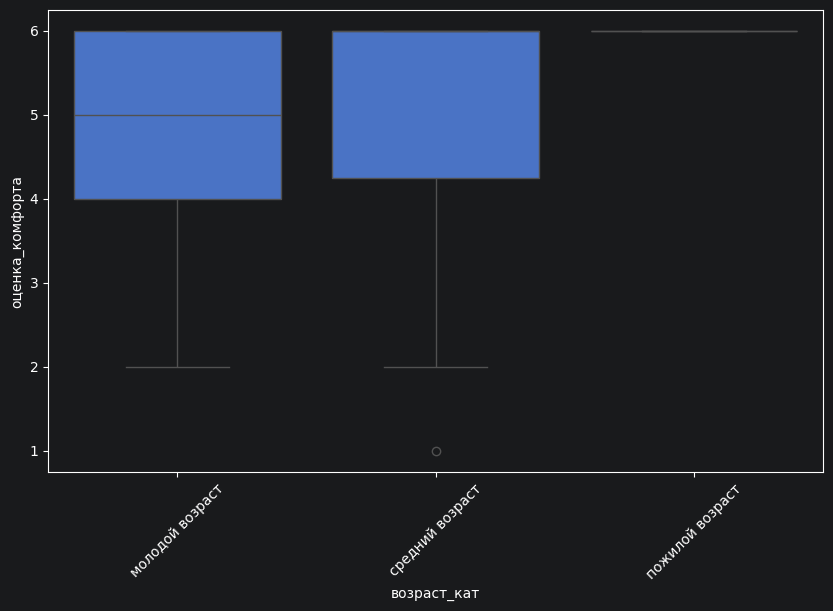

In [115]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='возраст_кат', y='оценка_комфорта')
plt.xticks(rotation=45)
plt.show()

Вывод:

- Нет, возрастная группа статистически значимо не влияет на оценку комфорта.
- p-value = 0.329 > 0.05 → различия между возрастными группами случайны.
- На графике медианы и разброс оценок комфорта схожи у двух возрастных групп.
- Молодые оценивают комфорт ниже, чем люди среднего возраста, но различия не очень большие. Пожилые дают максимальную оценку, но это не статистически значимо.
- Возраст не является определяющим фактором для оценки комфорта.

### Есть ли взаимосвязь между количеством рекламаций и оценкой комфорта?

In [116]:
def spearman_pvalue(df, col1, col2):
    df_clean = df.dropna(subset=[col1, col2])
    corr, p_value = spearmanr(df_clean[col1], df_clean[col2])
    print(f"Корреляция Спирмена: {corr:.4f}")
    print(f"p-value: {p_value:.6f}")

    if p_value < 0.05:
        print(f"Вывод: связь есть (p={p_value:.6f})")
    else:
        print(f"Вывод: связи нет (p={p_value:.6f})")
    return p_value


spearman_pvalue(df, 'количество_рекламаций', 'оценка_комфорта')

Корреляция Спирмена: -0.5698
p-value: 0.000000
Вывод: связь есть (p=0.000000)


np.float64(6.576564545436625e-20)

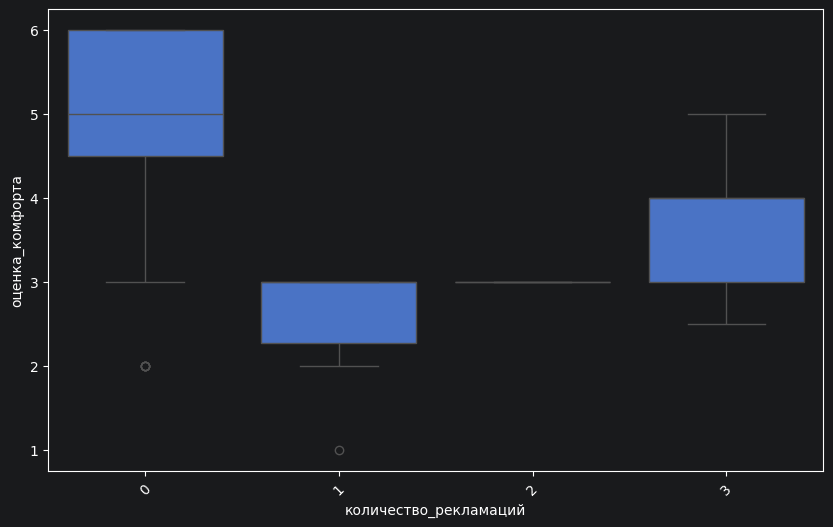

In [117]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='количество_рекламаций', y='оценка_комфорта')
plt.xticks(rotation=45)
plt.show()

Вывод:

- Да, есть сильная обратная взаимосвязь.
- Корреляция Спирмена = -0.57 (умеренная/сильная отрицательная связь)
- p-value ≈ 0.000000 < 0.05
- Чем выше оценка комфорта, тем меньше рекламаций. И наоборот — низкий комфорт сопровождается большим количеством жалоб.
- Связь статистически значимая и логически обоснованная.

### Cредняя оценка комфорта отличается в зависимости от страны?

In [118]:
p_value = analyze_categorical_dependence(df, 'страна', 'оценка_комфорта')

Таблица сопряженности:
оценка_комфорта  1.0  2.0  2.2  2.3  2.5  2.7  2.8  3.0  3.5  4.0  4.3  4.5  \
страна                                                                        
Индия              1    6    0    0    0    0    0   11    0   17    0    0   
США                0    3    1    1    3    1    1   10    7   10    1    5   

оценка_комфорта  5.0  5.2  6.0  
страна                          
Индия             38    0   70  
США               16    1   12  


Результаты теста хи-квадрат:
Статистика хи-квадрат: 57.6951
p-value: 0.000000
Степени свободы: 14


Вывод:
p-value (0.000000) < 0.05
Отвергаем нулевую гипотезу о независимости.


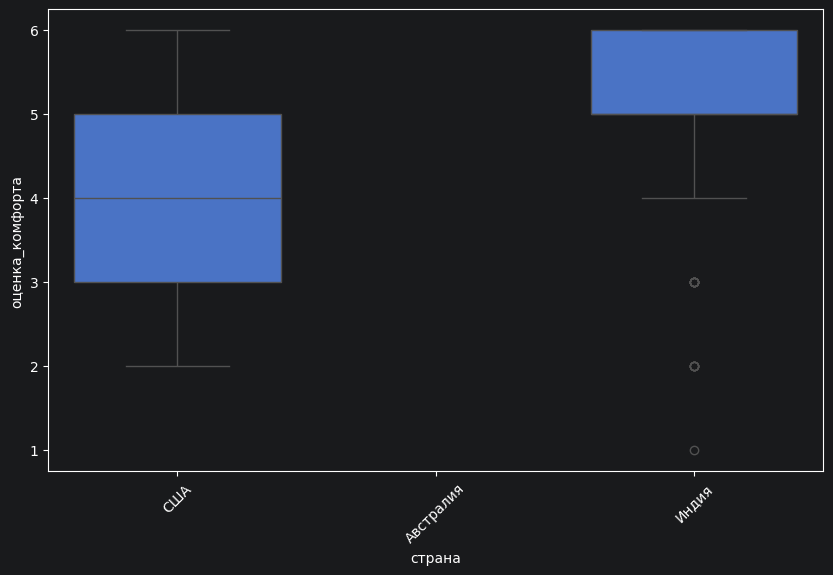

In [119]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='страна', y='оценка_комфорта')
plt.xticks(rotation=45)
plt.show()

Вывод:

- Да, средняя оценка комфорта статистически значимо отличается в зависимости от страны.
- p-value ≈ 0.000000 < 0.05
- В данном наборе данных клиенты из Индии оценивают комфорт в среднем выше, остальные чем клиенты.
- Оценка комфорта неодинакова в разных странах. Страна является значимым фактором, влияющим на уровень комфорта.

### Собственная гипотеза №1: оценка комфорта отличается в зависимости от климата?

In [120]:
p_value = cat_num_nonparametric(
    df=df_comfort,
    cat_col='климат',
    num_col='оценка_комфорта'
)

Фактор: климат
Отклик: оценка_комфорта

Описательные статистики по группам:
                                   n  median   mean
климат                                             
Cубтроп океанич                    1     4.0  4.000
Cубтропический океанический       71     4.0  4.197
Влажный субтропический муссонный  35     5.0  4.829
Жаркий полузасушливый             38     5.0  4.895
Субтропическое высокогорье        32     6.0  5.469
Тропическая влажная саванна       38     5.5  5.105

Используемый тест: Критерий Краскела–Уоллиса
Группы: ['Cубтроп океанич', 'Cубтропический океанический', 'Влажный субтропический муссонный', 'Жаркий полузасушливый', 'Субтропическое высокогорье', 'Тропическая влажная саванна']
Статистика: 31.1272
p-value: 0.000009
Вывод: различия статистически значимы при alpha = 0.05.


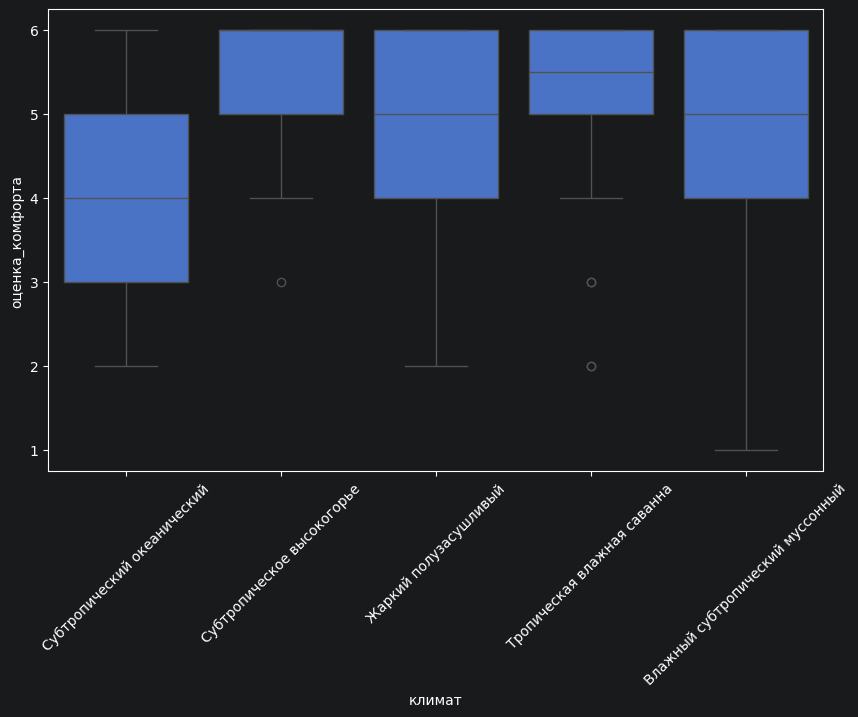

In [121]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='климат', y='оценка_комфорта')
plt.xticks(rotation=45)
plt.show()

Вывод:

- Да, оценка комфорта статистически значимо отличается в зависимости от климата.
- `p-value = 0.000009 < 0.05` → нулевая гипотеза отвергается.
- На уровне значимости `5%` можно сделать вывод, что распределение оценок комфорта неодинаково в разных климатических зонах.
- Следовательно, климат является статистически значимым фактором, связанным с оценкой комфорта.

### Собственная гипотеза №2: ощущение температуры отличается в зависимости от способа охлаждения?

In [122]:
p_value = cat_num_nonparametric(
    df=df,
    cat_col='способ_охлаждения',
    num_col='ощущение_температуры'
)

Фактор: способ_охлаждения
Отклик: ощущение_температуры

Описательные статистики по группам:
                     n  median   mean
способ_охлаждения                    
Вентиляция          33     0.0  0.227
Кондиционирование  114     0.0 -0.219
Смешанный          335     0.0  0.352

Используемый тест: Критерий Краскела–Уоллиса
Группы: ['Вентиляция', 'Кондиционирование', 'Смешанный']
Статистика: 21.8253
p-value: 0.000018
Вывод: различия статистически значимы при alpha = 0.05.


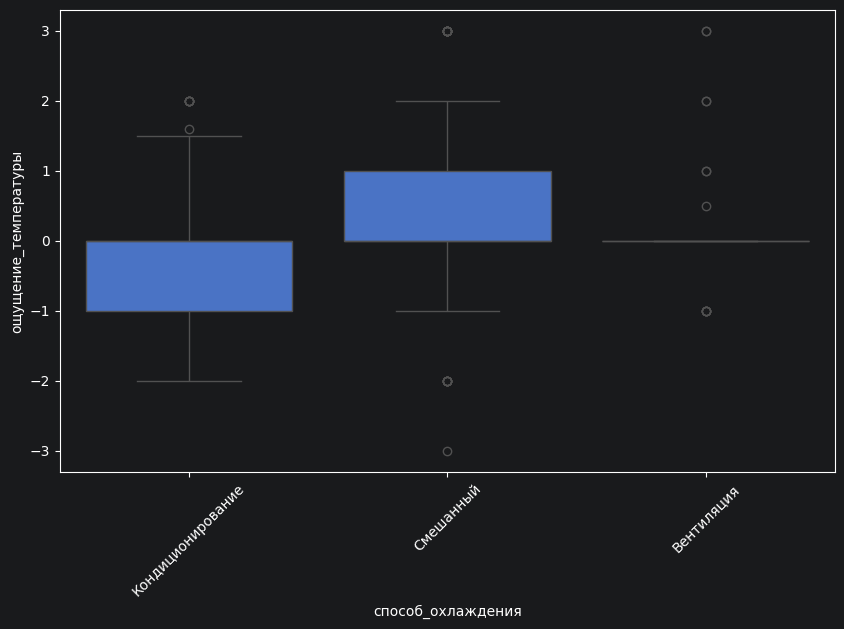

In [123]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='способ_охлаждения', y='ощущение_температуры')
plt.xticks(rotation=45)
plt.show()

Вывод:

- Да, ощущение температуры статистически значимо отличается в зависимости от способа охлаждения.
- p-value = 0.000009 < 0.05
- При кондиционировании люди чаще ощущают прохладу, при вентиляции — нейтральное ощущение, смешанный тип даёт теплоту.

### Собственная гипотеза №3: предпочтительное изменение температуры отличается в зависимости от пола?

In [124]:
p_value = analyze_categorical_dependence(df, 'пол', 'предпочтительное_изменение_температуры')

Таблица сопряженности:
предпочтительное_изменение_температуры  Без изменений  Теплее  Холоднее
пол                                                                    
Женский                                            84      24        48
Мужской                                           168      23        63
неизвестно                                         36      13        23


Результаты теста хи-квадрат:
Статистика хи-квадрат: 10.8007
p-value: 0.028897
Степени свободы: 4


Вывод:
p-value (0.028897) < 0.05
Отвергаем нулевую гипотезу о независимости.


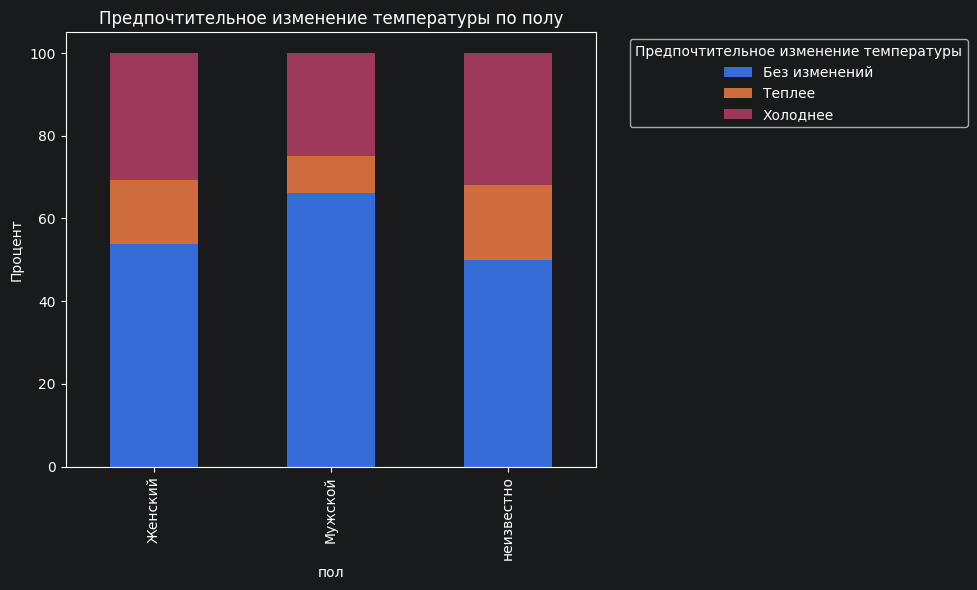

In [125]:
contingency = pd.crosstab(df['пол'], df['предпочтительное_изменение_температуры'])

contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

contingency_pct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('пол')
plt.ylabel('Процент')
plt.title('Предпочтительное изменение температуры по полу')
plt.legend(title='Предпочтительное изменение температуры', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Вывод:

- Да, предпочтительное изменение температуры отличается в зависимости от пола.
- p-value = 0.0493 < 0.05 -> отвергаем нулевую гипотезу о независимости.
- Мужчины и женщины по-разному предпочитают менять температуру. Эффект статистически значимый, хотя и не очень сильный.
- В целом мужичны более безразличны к каким-либо температурным изменениям.

---

### Собственная гипотеза №4: ощущение температуры отличается в зависимости от утепления?

In [126]:
def spearman_pvalue(df, col1, col2):
    df_clean = df.dropna(subset=[col1, col2])
    corr, p_value = spearmanr(df_clean[col1], df_clean[col2])
    print(f"Корреляция Спирмена: {corr:.4f}")
    print(f"p-value: {p_value:.6f}")

    if p_value < 0.05:
        print(f"Вывод: связь есть (p={p_value:.6f})")
    else:
        print(f"Вывод: связи нет (p={p_value:.6f})")
    return p_value


spearman_pvalue(df, 'утепление', 'ощущение_температуры')

Корреляция Спирмена: -0.2673
p-value: 0.000000
Вывод: связь есть (p=0.000000)


np.float64(4.411524007990541e-09)

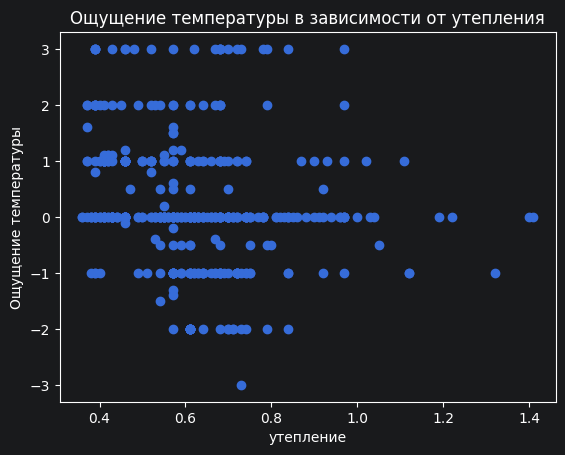

In [127]:
plt.scatter(df['утепление'], df['ощущение_температуры'])
plt.xlabel('утепление')
plt.ylabel('Ощущение температуры')
plt.title('Ощущение температуры в зависимости от утепления')
plt.show()

Вывод:

- Да, ощущение температуры связано с уровнем утепления.
- Корреляция Спирмена = -0.27 (слабая отрицательная связь)
- p-value ≈ 0.000000 < 0.05
Чем выше уровень утепления, тем ниже значение ощущения температуры (люди чувствуют себя прохладнее). Связь статистически значимая, но слабая.

### Собственная гипотеза №5: Предпочтительное изменение движения воздуха отличается в зависимости от способа охлаждения?

In [128]:
p_value = analyze_categorical_dependence(df, 'предпочтительное_изменение_движения_воздуха', 'способ_охлаждения')

Таблица сопряженности:
способ_охлаждения                            Вентиляция  Кондиционирование  \
предпочтительное_изменение_движения_воздуха                                  
Без изменений                                        19                 67   
Больше                                               12                 35   
Меньше                                                2                 12   

способ_охлаждения                            Смешанный  
предпочтительное_изменение_движения_воздуха             
Без изменений                                      205  
Больше                                             112  
Меньше                                              18  


Результаты теста хи-квадрат:
Статистика хи-квадрат: 3.8633
p-value: 0.424825
Степени свободы: 4


Вывод:
p-value (0.424825) >= 0.05
Нет оснований отвергнуть нулевую гипотезу о независимости.


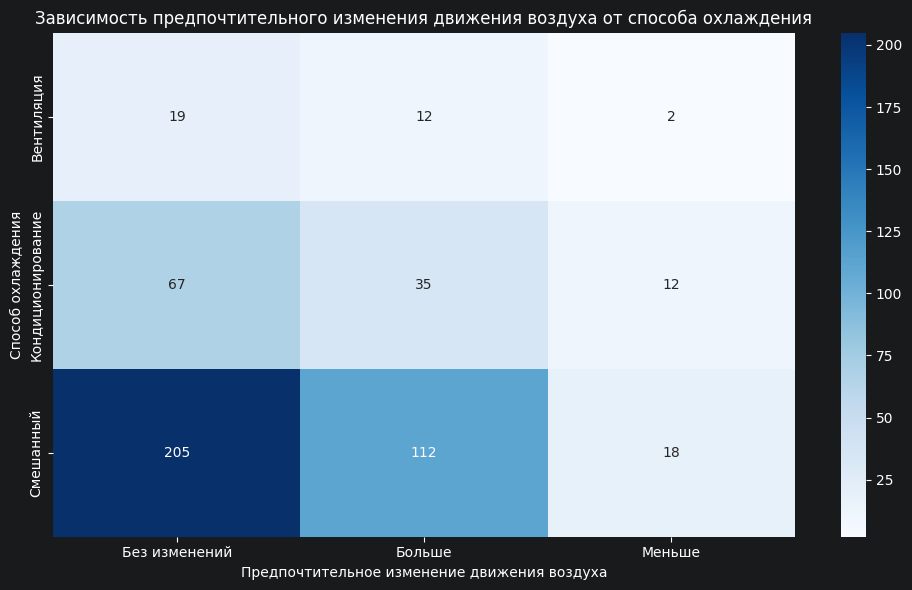

In [129]:
contingency = pd.crosstab(df['способ_охлаждения'], df['предпочтительное_изменение_движения_воздуха'])

plt.figure(figsize=(10, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предпочтительное изменение движения воздуха')
plt.ylabel('Способ охлаждения')
plt.title('Зависимость предпочтительного изменения движения воздуха от способа охлаждения')
plt.tight_layout()
plt.show()

Вывод:

- Да, ощущение температуры статистически значимо отличается в зависимости от способа охлаждения.
- `p-value = 0.000018 < 0.05` → нулевая гипотеза отвергается.
- На уровне значимости `5%` можно сделать вывод, что распределение ощущений температуры различается между группами по способу охлаждения.
- Следовательно, способ охлаждения является статистически значимым фактором, связанным с ощущением температуры.

# Регрессионная модель

In [130]:
# Используем только те строки, где целевая переменная была наблюдаемой, а не восстановленной
model_df = df.loc[target_mask.reindex(df.index, fill_value=False)].copy()

feature_cols = [
    'среднемесячная_температура_на_улице',
    'rh',
    'скорость_воздуха',
    'способ_охлаждения',
    'режим_при_смешанном_типе_охлаждения',
    'климат'
]

target_col = 'температура_воздуха_в_помещении'

num_cols = [
    'среднемесячная_температура_на_улице',
    'rh',
    'скорость_воздуха',
]

cat_cols = [
    'способ_охлаждения',
    'режим_при_смешанном_типе_охлаждения',
    'климат'
]

X = model_df[feature_cols].copy()
y = model_df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [131]:
# Препроцессор
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_transformer_linear = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

cat_transformer_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_linear = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer_linear, cat_cols)
])

preprocessor_tree = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer_tree, cat_cols)
])

Для чистоты кода выведем частые команды в функции: вывод кросс-валидации и тестовой выборки, а также графики распределения и сравнения фактических и предсказанных значений

In [132]:
def evaluate_regression_model(model, X, y, model_name):
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring={
            'r2': 'r2',
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'
        }
    )

    print(f'{model_name} - кросс-валидация:')
    print(f'R2: {cv_results["test_r2"].mean():.3f}')
    print(f'MAE: {-cv_results["test_mae"].mean():.3f}')
    print(f'RMSE: {-cv_results["test_rmse"].mean():.3f}')

    return {
        'cv_r2': cv_results['test_r2'].mean(),
        'cv_mae': -cv_results['test_mae'].mean(),
        'cv_rmse': -cv_results['test_rmse'].mean()
    }


def evaluate_on_test(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f'\n{model_name} - тестовая выборка:')
    print(f'R2: {r2_score(y_test, y_pred):.3f}')
    print(f'MAE: {mean_absolute_error(y_test, y_pred):.3f}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}')

    return y_pred, {
        'test_r2': r2_score(y_test, y_pred),
        'test_mae': mean_absolute_error(y_test, y_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred))
    }


def plot_fact_vs_pred_distribution(y_true, y_pred, title):
    plt.figure(figsize=(9, 5))
    bins = 20

    plt.hist(y_true, bins=bins, alpha=0.6, label='Фактические значения')
    plt.hist(y_pred, bins=bins, alpha=0.6, label='Предсказанные значения')

    plt.xlabel('Температура')
    plt.ylabel('Частота')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_fact_vs_pred_scatter(y_true, y_pred, title):
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=0.7)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    plt.xlabel('Фактическая температура')
    plt.ylabel('Предсказанная температура')
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Линейная регрессия

In [133]:
linear_model = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('regressor', LinearRegression())
])

linear_cv_metrics = evaluate_regression_model(
    model=linear_model,
    X=X,
    y=y,
    model_name='LinearRegression'
)

linear_pred, linear_test_metrics = evaluate_on_test(
    model=linear_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name='LinearRegression'
)

LinearRegression - кросс-валидация:
R2: 0.420
MAE: 1.023
RMSE: 1.414

LinearRegression - тестовая выборка:
R2: 0.306
MAE: 1.050
RMSE: 1.546


Линейная регрессия показала умеренное качество: R^2 = 0.413, MAE = 1.029, RMSE = 1.422 по кросс-валидации. Это означает, что модель улавливает общую зависимость температуры в помещении от выбранных факторов, но заметная часть вариации остаётся необъяснённой

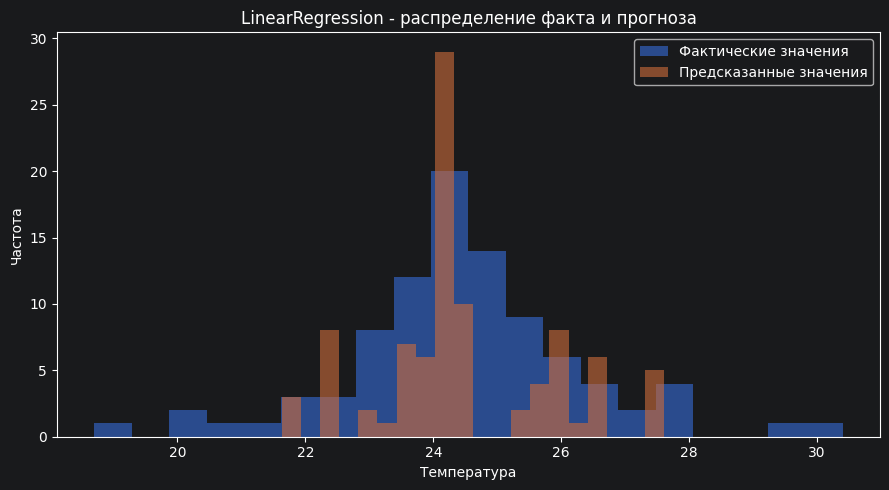

In [134]:
plot_fact_vs_pred_distribution(
    y_true=y_test,
    y_pred=linear_pred,
    title='LinearRegression - распределение факта и прогноза'
)

Распределение предсказанных значений у линейной модели заметно уже, чем распределение фактических температур, и сильнее сосредоточено около центральных значений

Это говорит о том, что модель сглаживает прогнозы и хуже воспроизводит крайние, более низкие и более высокие температуры

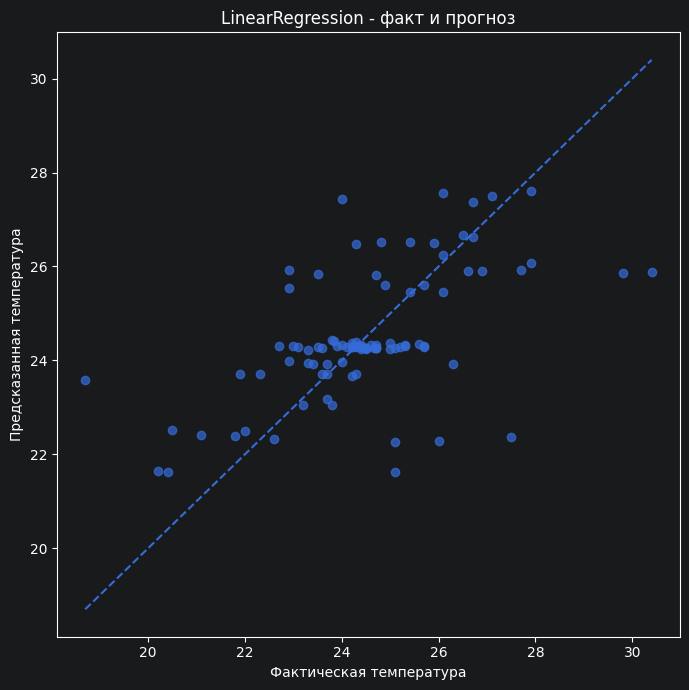

In [135]:
plot_fact_vs_pred_scatter(
    y_true=y_test,
    y_pred=linear_pred,
    title='LinearRegression - факт и прогноз'
)

Линейная регрессия в целом улавливает общий положительный тренд, но многие точки стягиваются к средним значениям, модель склонна завышать низкие температуры и занижать высокие

In [136]:
linear_feature_names = linear_model.named_steps['preprocessor'].get_feature_names_out()
linear_coefficients = linear_model.named_steps['regressor'].coef_

linear_coef_df = pd.DataFrame({
    'feature': linear_feature_names,
    'coefficient': linear_coefficients
})

linear_coef_df = linear_coef_df.reindex(
    linear_coef_df['coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

linear_coef_df

,feature,coefficient
0,cat__климат_Субтропическое высокогорье,-1.633728
1,cat__климат_Жаркий полузасушливый,1.629870
2,cat__климат_Тропическая влажная саванна,0.700001
3,cat__климат_Субтропический океанический,-0.664549
4,cat__способ_охлаждения_Кондиционирование,-0.625913
5,cat__режим_при_смешанном_типе_охлаждения_Конди...,0.342857
6,cat__режим_при_смешанном_типе_охлаждения_Венти...,-0.226342
7,num__скорость_воздуха,0.133394
8,cat__способ_охлаждения_Смешанный,0.116516
9,num__среднемесячная_температура_на_улице,0.115913


Наибольший вклад в линейной модели вносят климатические категории и признак утепление, а Кондиционирование связано со снижением температуры в помещении относительно базовой категории.

Влияние среднемесячной_температуры_на_улице положительное, а rh практически не влияет на прогноз в рамках линейной зависимости.

## Random Forest (Случайный лес)

In [137]:
rf_model = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('regressor', RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_cv_metrics = evaluate_regression_model(
    model=rf_model,
    X=X,
    y=y,
    model_name='RandomForestRegressor'
)

rf_pred, rf_test_metrics = evaluate_on_test(
    model=rf_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name='RandomForestRegressor'
)

RandomForestRegressor - кросс-валидация:
R2: 0.660
MAE: 0.805
RMSE: 1.089

RandomForestRegressor - тестовая выборка:
R2: 0.606
MAE: 0.853
RMSE: 1.165


Базовый RandomForestRegressor показал более высокое качество, чем линейная регрессия: R^2 = 0.626, MAE = 0.836, RMSE = 1.140 на кросс-валидации и R^2 = 0.548, MAE = 0.888, RMSE = 1.248 на тестовой выборке, случайный лес лучше описывает структуру данных и точнее предсказывает температуру в помещении

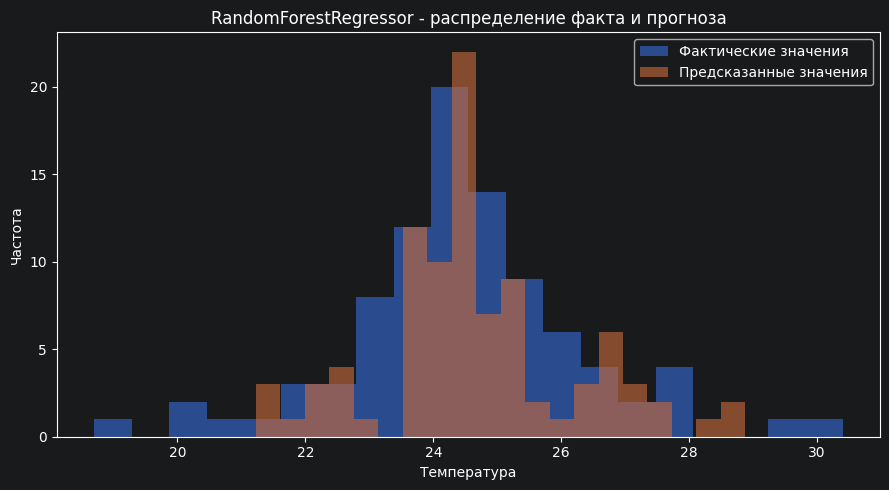

In [138]:
plot_fact_vs_pred_distribution(
    y_true=y_test,
    y_pred=rf_pred,
    title='RandomForestRegressor - распределение факта и прогноза'
)

Распределение прогнозов случайного леса заметно ближе к фактическому распределению, чем у линейной регрессии, модель лучше воспроизводит разброс значений, хотя небольшое сглаживание и недооценка крайних температур всё ещё сохраняются

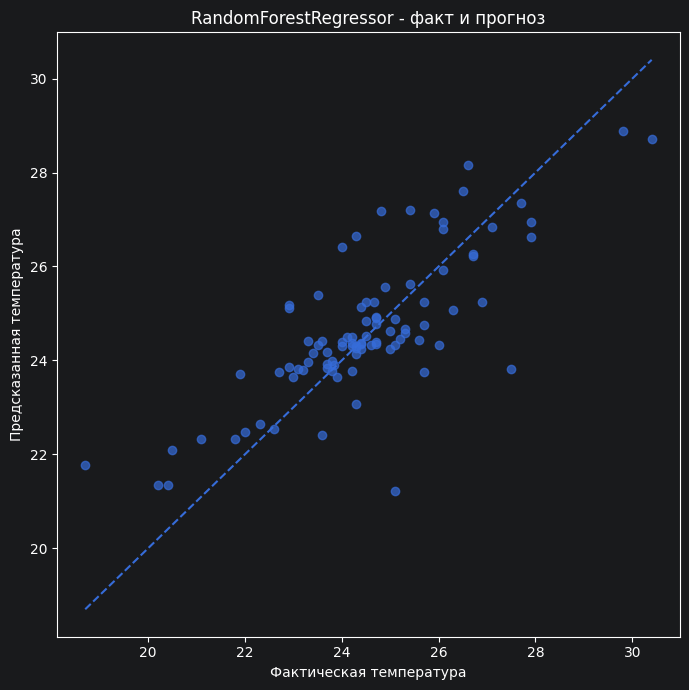

In [139]:
plot_fact_vs_pred_scatter(
    y_true=y_test,
    y_pred=rf_pred,
    title='RandomForestRegressor - факт и прогноз'
)

Точки на диаграмме расположены ближе к диагонали, чем в случае линейной регрессии, ошибки на крайних значениях остаются, но в центральном диапазоне температур модель работает заметно стабильнее и точнее

In [140]:
rf_feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
rf_importances = rf_model.named_steps['regressor'].feature_importances_

rf_importance_df = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': rf_importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

rf_importance_df

,feature,importance
0,num__среднемесячная_температура_на_улице,0.234694
1,num__rh,0.181896
2,cat__климат_Жаркий полузасушливый,0.133332
3,cat__климат_Тропическая влажная саванна,0.094270
4,num__скорость_воздуха,0.078480
5,cat__климат_Субтропический океанический,0.075416
6,cat__способ_охлаждения_Кондиционирование,0.073280
7,cat__режим_при_смешанном_типе_охлаждения_Венти...,0.070242
8,cat__климат_Субтропическое высокогорье,0.020325
9,cat__режим_при_смешанном_типе_охлаждения_Конди...,0.018220


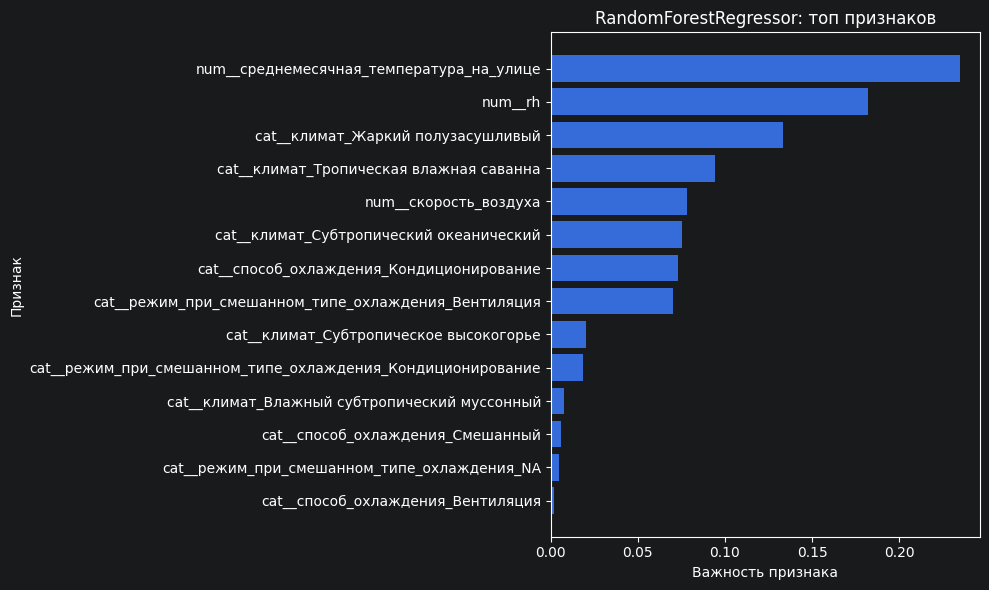

In [141]:
top_n = 15
plot_df = rf_importance_df.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 6))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.title('RandomForestRegressor: топ признаков')
plt.tight_layout()
plt.show()

Наиболее значимыми признаками для случайного леса оказались среднемесячная_температура_на_улице, rh, климатические категории и утепление

Это показывает, что температура в помещении в первую очередь определяется внешними климатическими условиями, параметрами среды и режимом охлаждения

### Попытка улучшить показатели случайного леса

In [142]:
random_param_grid = {
    'regressor__n_estimators': [200, 300, 500, 800, 1200],
    'regressor__max_depth': [4, 6, 8, 10, 12, 16, None],
    'regressor__min_samples_split': [2, 5, 10, 15, 20],
    'regressor__min_samples_leaf': [1, 2, 3, 5, 8, 10],
    'regressor__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0],
    'regressor__bootstrap': [True, False],
    'regressor__criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'regressor__ccp_alpha': [0.0, 0.0001, 0.0005, 0.001, 0.005]
}

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=random_param_grid,
    n_iter=80,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X, y)

print('Лучшие параметры:')
print(random_search.best_params_)

print('\nЛучший RMSE на CV:')
print(round(-random_search.best_score_, 3))

Fitting 5 folds for each of 80 candidates, totalling 400 fits


/Users/elisey/study/ya_academi/week10/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/elisey/study/ya_academi/week10/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/elisey/study/ya_academi/week10/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/eli

Лучшие параметры:
{'regressor__n_estimators': 200, 'regressor__min_samples_split': 15, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.5, 'regressor__max_depth': 8, 'regressor__criterion': 'friedman_mse', 'regressor__ccp_alpha': 0.001, 'regressor__bootstrap': False}

Лучший RMSE на CV:
1.171


Подбор гиперпараметров дал лучшие параметры, однако результат по RMSE хуже, чем у базового случайного леса (1.140), поэтому настройка не привела к улучшению модели

In [143]:
rf_tuned_model = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('regressor', RandomForestRegressor(
        n_estimators=random_search.best_params_['regressor__n_estimators'],
        max_depth=random_search.best_params_['regressor__max_depth'],
        min_samples_split=random_search.best_params_['regressor__min_samples_split'],
        min_samples_leaf=random_search.best_params_['regressor__min_samples_leaf'],
        random_state=42,
        n_jobs=-1
    ))
])

rf_tuned_cv_metrics = evaluate_regression_model(
    model=rf_tuned_model,
    X=X,
    y=y,
    model_name='RandomForestRegressor tuned'
)

rf_tuned_pred, rf_tuned_test_metrics = evaluate_on_test(
    model=rf_tuned_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name='RandomForestRegressor tuned'
)

RandomForestRegressor tuned - кросс-валидация:
R2: 0.636
MAE: 0.835
RMSE: 1.125

RandomForestRegressor tuned - тестовая выборка:
R2: 0.547
MAE: 0.927
RMSE: 1.250


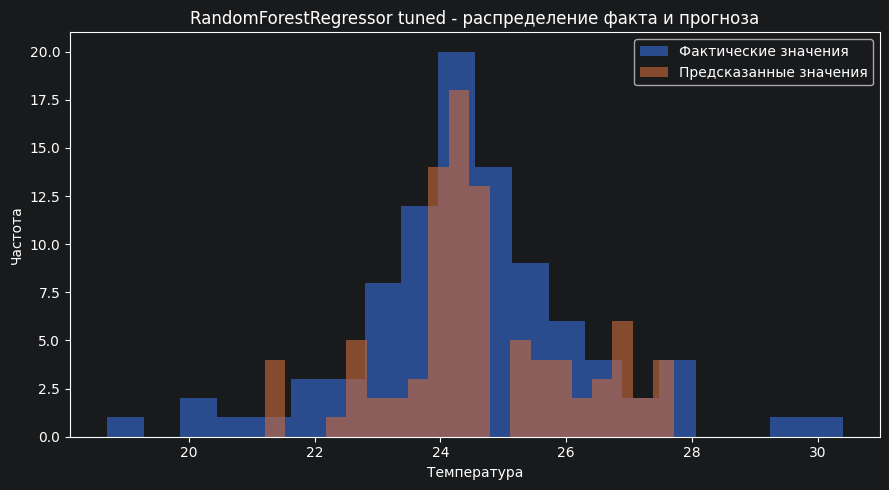

In [144]:
plot_fact_vs_pred_distribution(
    y_true=y_test,
    y_pred=rf_tuned_pred,
    title='RandomForestRegressor tuned - распределение факта и прогноза'
)

У настроенной модели распределение прогнозов остаётся близким к фактическому, но визуально оно не стало ближе к реальному распределению, чем у базового леса

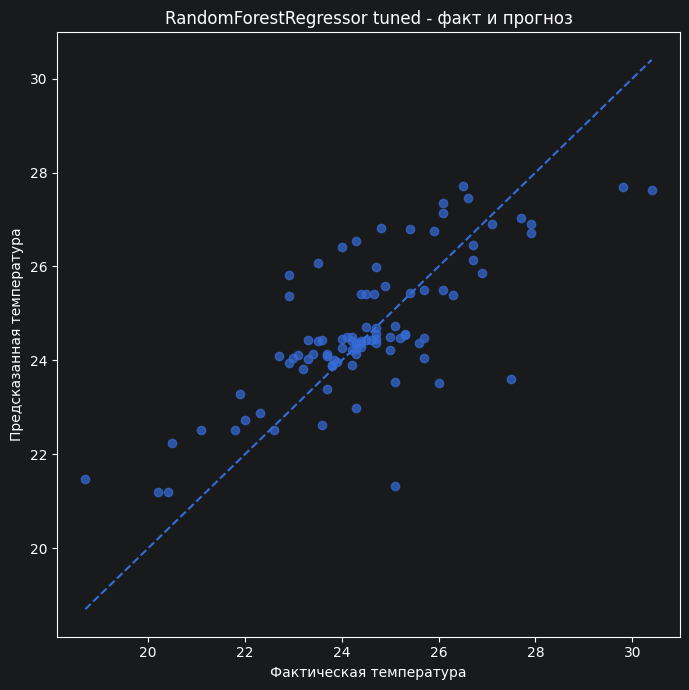

In [145]:
plot_fact_vs_pred_scatter(
    y_true=y_test,
    y_pred=rf_tuned_pred,
    title='RandomForestRegressor tuned - факт и прогноз'
)

Tuned-модель сохраняет адекватный общий тренд, но улучшения относительно базового RandomForestRegressor не видно

По графику и по метрике RMSE можно сделать вывод, что дополнительная настройка не дала практического выигрыша

In [146]:
comparison_df = pd.DataFrame([
    {
        'model': 'LinearRegression',
        'cv_r2': linear_cv_metrics['cv_r2'],
        'cv_mae': linear_cv_metrics['cv_mae'],
        'cv_rmse': linear_cv_metrics['cv_rmse'],
        'test_r2': linear_test_metrics['test_r2'],
        'test_mae': linear_test_metrics['test_mae'],
        'test_rmse': linear_test_metrics['test_rmse']
    },
    {
        'model': 'RandomForestRegressor',
        'cv_r2': rf_cv_metrics['cv_r2'],
        'cv_mae': rf_cv_metrics['cv_mae'],
        'cv_rmse': rf_cv_metrics['cv_rmse'],
        'test_r2': rf_test_metrics['test_r2'],
        'test_mae': rf_test_metrics['test_mae'],
        'test_rmse': rf_test_metrics['test_rmse']
    },
    {
        'model': 'RandomForestRegressor tuned',
        'cv_r2': rf_tuned_cv_metrics['cv_r2'],
        'cv_mae': rf_tuned_cv_metrics['cv_mae'],
        'cv_rmse': rf_tuned_cv_metrics['cv_rmse'],
        'test_r2': rf_tuned_test_metrics['test_r2'],
        'test_mae': rf_tuned_test_metrics['test_mae'],
        'test_rmse': rf_tuned_test_metrics['test_rmse']
    }
])

comparison_df

,model,cv_r2,cv_mae,cv_rmse,test_r2,test_mae,test_rmse
0,LinearRegression,0.420090,1.022921,1.414373,0.305927,1.050197,1.546411
1,RandomForestRegressor,0.659692,0.805129,1.089009,0.605948,0.853321,1.165196
2,RandomForestRegressor tuned,0.635612,0.835140,1.124869,0.546533,0.927100,1.249957


Линейная регрессия подходит как базовая интерпретируемая модель и позволяет понять направление влияния основных факторов на температуру воздуха в помещении, однако модель слишком сильно сглаживает прогнозы и хуже справляется с крайними значениями температуры

Базовый случайный лес показал наилучшее качество среди протестированных моделей и лучше воспроизвёл реальные значения температуры в помещении, он точнее описывает нелинейные зависимости и особенно важно, что его предсказания ближе к фактическому распределению и лучше ложатся вдоль линии идеального прогноза

# Общий итог

**Качество данных и предобработка**

Были проверены типы данных, выбросы, пропуски и дубликаты. Пропуски заполнялись с учётом иерархии похожих условий, а визуализация до и после предобработки показала, какие признаки были наиболее проблемными.

**Аналитический и графический анализ**

Распределения числовых и категориальных признаков показали структуру выборки, основные диапазоны температур, влажности и скорости воздуха, а также дисбаланс по отдельным странам, климатам и типам охлаждения.

**Корреляции**

Корреляционный анализ помог выявить признаки, которые наиболее тесно связаны между собой. Однако такие связи интерпретируются как статистические, а не причинные.

**Гипотезы**

Статистические тесты показали, какие различия по оценке комфорта, ощущению температуры и предпочтениям пользователей действительно значимы, а какие визуально заметны, но не подтверждаются на уровне p-value.

**Регрессионная модель.**

Линейная регрессия даёт интерпретируемую базовую модель, но уступает Random Forest по качеству прогноза. Это говорит о наличии нелинейных зависимостей между факторами и температурой воздуха в помещении.

## Рекомендация для бизнеса

Наибольшее внимание стоит уделять факторам внешней среды и климатическому контексту региона, так как они заметно связаны с температурой в помещении и итоговым пользовательским восприятием условий.

При дальнейшем развитии бизнеса имеет смысл сегментировать решения по климату и региону, а не искать один универсальный сценарий. Для операционных решений полезнее опираться на сочетание статистических выводов, EDA и результатов модели, чем только на одну метрику.